# Candidate sites, demand and travel-time matrices
Build the inputs for the station-placement optimization:

- **Candidates**: existing fire halls and towns from OpenStreetMap.
- **Demand**: fire ignitions from `03_eda_firms`, split into train (2019–2022) and test (2023).
- **Cost**: estimated travel time in minutes from every candidate to every fire.

Everything is saved to `data/processed/model/`. Nothing is optimized here.

## Config
Every setting lives in this cell.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import sys
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from pyproj import Transformer
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from IPython.display import display

folder = Path.cwd().resolve()
REPO_ROOT = next((p for p in (folder, *folder.parents) if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch from inside the repository.")
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from bc_geo import load_bc_boundary

# Travel-time model
DETOUR = 1.4          # road distance / straight-line distance
SPEED_KMH = 70        # truck speed
DISPATCH_MIN = 10     # minutes before the truck leaves
THRESHOLD_MIN = 60    # a fire is "covered" if a station reaches it within this time

# Demand and candidates
CELL_KM = 10          # demand-cell size
HALL_MERGE_M = 200    # fire-hall features this close are one hall
TOWN_MERGE_KM = 5     # places this close are one town
TRAIN_YEARS = [2019, 2020, 2021, 2022]
TEST_YEARS = [2023]
PLACE_RANK = {"city": 3, "town": 2, "village": 1}
EARTH_RADIUS_KM = 6371.0088

# OpenStreetMap via the Overpass API (cached; delete the file to query again)
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
OVERPASS_TIMEOUT_S = 300
OVERPASS_ATTEMPTS = 3
# The server rejects requests without a descriptive User-Agent (HTTP 406).
OVERPASS_USER_AGENT = "ember-command/0.1 (BC fire-station placement, hackathon project)"
OVERPASS_QUERY = f"""
[out:json][timeout:{OVERPASS_TIMEOUT_S}];
area["ISO3166-2"="CA-BC"]["admin_level"="4"]->.bc;
(
  nwr["amenity"="fire_station"](area.bc);
  nwr["building"="fire_station"](area.bc);
  nwr["emergency"="fire_service"](area.bc);
  nwr["place"~"^(city|town|village)$"](area.bc);
);
out center tags;
"""

OSM_CACHE = REPO_ROOT / "data" / "reference" / "osm_bc_halls_places.json"
IGNITIONS_PATH = REPO_ROOT / "data" / "processed" / "ignitions.parquet"
MODEL_DIR = REPO_ROOT / "data" / "processed" / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

to_albers = Transformer.from_crs("EPSG:4326", "EPSG:3005", always_xy=True)
bc = load_bc_boundary()
bc_shape = bc.geometry.iloc[0]

## 1. OpenStreetMap features
One Overpass query for all of BC: fire halls (`amenity=fire_station`, `building=fire_station`,
`emergency=fire_service`) and places (`place` = city, town or village). `out center tags` gives every
feature one coordinate: a node's own position, or the centre of a way or relation.
The raw response is cached; if the cache exists it is read instead of querying.

In [2]:
if OSM_CACHE.exists():
    print(f"Reading cached Overpass response: {OSM_CACHE.relative_to(REPO_ROOT)}")
else:
    for attempt in range(1, OVERPASS_ATTEMPTS + 1):
        print(f"Overpass query, attempt {attempt}/{OVERPASS_ATTEMPTS}")
        try:
            response = requests.post(OVERPASS_URL, data={"data": OVERPASS_QUERY},
                                     headers={"User-Agent": OVERPASS_USER_AGENT},
                                     timeout=(30, OVERPASS_TIMEOUT_S + 60))
            response.raise_for_status()
            payload = response.json()
            if not payload.get("elements"):
                raise ValueError(f"empty result: {payload.get('remark', 'no remark')}")
        except (requests.RequestException, ValueError) as error:
            print(f"  failed: {str(error)[:300]}")
            if attempt == OVERPASS_ATTEMPTS:
                raise RuntimeError("Overpass failed; no OSM data was saved.") from None
            time.sleep(30 * attempt)
        else:
            OSM_CACHE.write_text(response.text, encoding="utf-8")
            break

osm = json.loads(OSM_CACHE.read_text(encoding="utf-8"))
OSM_QUERY_DATE = datetime.fromtimestamp(OSM_CACHE.stat().st_mtime, tz=timezone.utc).strftime("%Y-%m-%d")
OSM_DATA_TIMESTAMP = osm.get("osm3s", {}).get("timestamp_osm_base", "")
print(f"{len(osm['elements']):,} features; queried {OSM_QUERY_DATE}; OSM data as of {OSM_DATA_TIMESTAMP}")

Overpass query, attempt 1/3


1,031 features; queried 2026-10-04; OSM data as of 2026-10-04T12:18:51Z


In [3]:
rows = []
for element in osm["elements"]:
    position = element if element["type"] == "node" else element.get("center", {})
    tags = element.get("tags", {})
    rows.append({"osm_type": element["type"], "osm_id": element["id"],
                 "lat": position.get("lat"), "lon": position.get("lon"), "name": tags.get("name"),
                 "amenity": tags.get("amenity"), "building": tags.get("building"),
                 "emergency": tags.get("emergency"), "place": tags.get("place"),
                 "population": tags.get("population")})
features = pd.DataFrame(rows).sort_values(["osm_type", "osm_id"]).reset_index(drop=True)
if features[["lat", "lon"]].isna().any().any():
    raise ValueError("Some OSM features have no coordinate.")
features["x"], features["y"] = to_albers.transform(features["lon"].to_numpy(), features["lat"].to_numpy())
features["in_bc"] = gpd.GeoSeries(gpd.points_from_xy(features["lon"], features["lat"]),
                                  crs="EPSG:4326").within(bc_shape).to_numpy()
features["is_hall"] = ((features["amenity"] == "fire_station") | (features["building"] == "fire_station")
                       | (features["emergency"] == "fire_service"))
features["is_place"] = features["place"].isin(list(PLACE_RANK))
print(features.groupby(["is_hall", "is_place", "osm_type"]).size().rename("features").to_string())
print(f"\nOutside the BC boundary (dropped): {(~features['in_bc']).sum()} "
      f"({(features['is_hall'] & ~features['in_bc']).sum()} hall features, "
      f"{(features['is_place'] & ~features['in_bc']).sum()} places)")
outside_places = features[features["is_place"] & ~features["in_bc"]]
if len(outside_places):
    print("Places dropped:", ", ".join(sorted(outside_places["name"].fillna("(unnamed)"))))


def merge_groups(frame, radius_m):
    """Label rows so that points within radius_m of each other (directly or in a chain) share a label."""
    xy = frame[["x", "y"]].to_numpy()
    pairs = cKDTree(xy).query_pairs(radius_m, output_type="ndarray")
    graph = coo_matrix((np.ones(len(pairs), dtype=bool), (pairs[:, 0], pairs[:, 1])), shape=(len(frame), len(frame)))
    return connected_components(graph, directed=False)[1]

is_hall  is_place  osm_type
False    True      node        400
                   relation      2
                   way           9
True     False     node         98
                   relation      3
                   way         519

Outside the BC boundary (dropped): 76 (39 hall features, 37 places)
Places dropped: Ahousaht, Alert Bay, Belcarra, Bella Bella, Bella Coola, Bliss Landing, Caspaco, Comox, Cowichan Bay, Egmont, Esquimalt, Ging̱olx, Gwayasdums, Hartley Bay, Hesquiaht 6, Houpsitas, Kitamaat, Kitkatla, Kyuquot, Ladysmith, Lantzville, Masset, Mayne, Metlakatla, Nanaimo, North Vancouver, Opitsaht, Port Alice, Port Clements, Port Edward, Port Renfrew, Quathiaski Cove, Rivers Inlet, Spune’luxutth, Tofino, Van Anda, West Vancouver


## 2. Existing fire halls
Keep hall features inside BC and merge those within 200 m of each other (a hall is often mapped as both a
point and a building). A merged hall sits at the mean position and takes the first available name.

Hall features inside BC, by tag (a feature can have more than one):
{'amenity=fire_station': 492, 'building=fire_station': 155, 'emergency=fire_service': 0}
581 features -> 489 halls after merging within 200 m (455 named)


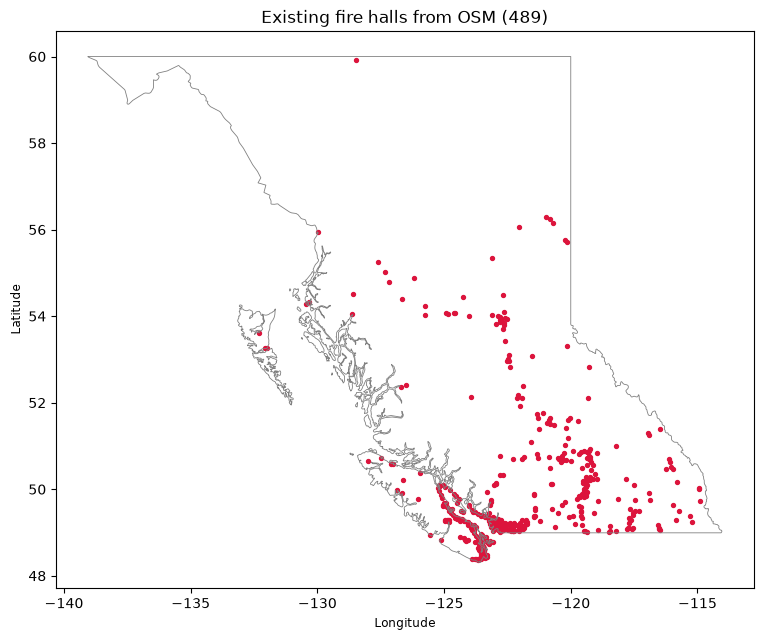

In [4]:
hall_features = features[features["is_hall"] & features["in_bc"]].copy()
print("Hall features inside BC, by tag (a feature can have more than one):")
print({"amenity=fire_station": int((hall_features["amenity"] == "fire_station").sum()),
       "building=fire_station": int((hall_features["building"] == "fire_station").sum()),
       "emergency=fire_service": int((hall_features["emergency"] == "fire_service").sum())})
hall_features["group"] = merge_groups(hall_features, HALL_MERGE_M)
halls = (hall_features.groupby("group")
         .agg(name=("name", "first"), lat=("lat", "mean"), lon=("lon", "mean"), features=("osm_id", "size"))
         .reset_index(drop=True))  # "first" skips missing names
print(f"{len(hall_features)} features -> {len(halls)} halls after merging within {HALL_MERGE_M} m "
      f"({halls['name'].notna().sum()} named)")

fig, ax = plt.subplots(figsize=(9, 8))
bc.boundary.plot(ax=ax, color="grey", linewidth=0.6)
ax.scatter(halls["lon"], halls["lat"], s=8, color="crimson")
ax.set(title=f"Existing fire halls from OSM ({len(halls)})", xlabel="Longitude", ylabel="Latitude")
plt.show()

## 3. Towns
Places tagged city, town or village inside BC. Places within 5 km of each other are merged into one, keeping
the one with the highest population, or the highest rank (city > town > village) where population is missing.

374 places -> 301 towns after merging within 5 km
{'village': 206, 'town': 55, 'city': 40} | with population: 143


,name,place,population,lat,lon
60,Vancouver,city,662248,49.260872,-123.113952
48,Surrey,city,568322,49.191303,-122.849143
59,Burnaby,city,249125,49.243380,-122.972545
42,Richmond,city,209937,49.163168,-123.137414
25,Abbotsford,city,153524,49.052116,-122.329479
64,Coquitlam,city,148625,49.284296,-122.793281
126,Kelowna,city,144576,49.887918,-119.495902
38,Langley Township,town,132603,49.120294,-122.659331


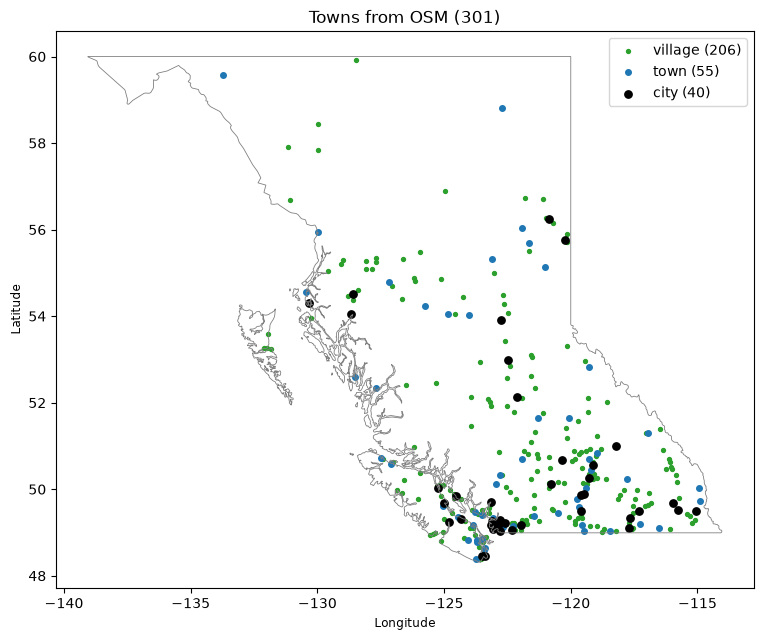

In [5]:
place_features = features[features["is_place"] & features["in_bc"]].copy()
place_features["population"] = pd.to_numeric(
    place_features["population"].astype("string").str.replace(r"[,\s]", "", regex=True), errors="coerce")
place_features["rank"] = place_features["place"].map(PLACE_RANK)
place_features["group"] = merge_groups(place_features, TOWN_MERGE_KM * 1000)
towns = (place_features.sort_values(["population", "rank", "name"], ascending=[False, False, True], na_position="last")
         .drop_duplicates("group")[["name", "place", "population", "lat", "lon"]]
         .sort_values(["lat", "lon"]).reset_index(drop=True))
print(f"{len(place_features)} places -> {len(towns)} towns after merging within {TOWN_MERGE_KM} km")
print(towns["place"].value_counts().to_dict(), f"| with population: {towns['population'].notna().sum()}")
display(towns.nlargest(8, "population"))

fig, ax = plt.subplots(figsize=(9, 8))
bc.boundary.plot(ax=ax, color="grey", linewidth=0.6)
for place, color, size in [("village", "tab:green", 8), ("town", "tab:blue", 16), ("city", "black", 28)]:
    subset = towns[towns["place"] == place]
    ax.scatter(subset["lon"], subset["lat"], s=size, color=color, label=f"{place} ({len(subset)})")
ax.set(title=f"Towns from OSM ({len(towns)})", xlabel="Longitude", ylabel="Latitude")
ax.legend()
plt.show()

## 4. Candidates
All towns plus all halls in one table. Halls are not merged with towns: Q3 needs the halls as their own set.
`cand_id` is the column index in the cost matrices (sorted by kind, then latitude and longitude).

In [6]:
candidates = pd.concat([halls[["name", "lat", "lon"]].assign(kind="hall", population=np.nan),
                        towns[["name", "lat", "lon", "population"]].assign(kind="town")], ignore_index=True)
candidates = candidates.sort_values(["kind", "lat", "lon"]).reset_index(drop=True)
candidates.insert(0, "cand_id", np.arange(len(candidates)))
candidates = candidates[["cand_id", "name", "lat", "lon", "kind", "population"]]
is_town = (candidates["kind"] == "town").to_numpy()
is_hall = (candidates["kind"] == "hall").to_numpy()
print(f"{len(candidates)} candidates: {is_hall.sum()} halls + {is_town.sum()} towns")
display(candidates.groupby("kind").head(3))

790 candidates: 489 halls + 301 towns


,cand_id,name,lat,lon,kind,population
0,0,East Sooke Volunteer Fire Department,48.362616,-123.670337,hall,<NA>
1,1,Metchosin Volunteer Fire Department,48.380611,-123.534912,hall,<NA>
2,2,Sooke Fire Rescue Station No. 1,48.382637,-123.731657,hall,<NA>
489,489,Metchosin,48.379601,-123.535234,town,5067.0
490,490,Sooke,48.382572,-123.731517,town,15086.0
491,491,Langford,48.449769,-123.504666,town,46584.0


## 5. Demand
Fires from the fire table, without static heat-source suspects. Train is 2019–2022, test is 2023.
**Row order is the matrix row order**; it is saved as is and never re-sorted.

`demand_cells` aggregates the train fires into 10 km cells (BC Albers): each cell sits at the
weight-averaged position of its fires and carries their summed weight.

In [7]:
ignitions = pd.read_parquet(IGNITIONS_PATH)
STATIC_EXCLUDED = int(ignitions["static_suspect"].sum())
WEIGHT_CAP = float(ignitions["weight"].max())  # the cap from step 1; fires at the cap carry exactly this weight
DEMAND_COLUMNS = ["fire_id", "year", "lat", "lon", "weight", "ignition_time_utc",
                  "first_date", "last_date", "active_days_capped"]
demand = ignitions.loc[~ignitions["static_suspect"], DEMAND_COLUMNS]
demand_train = demand[demand["year"].isin(TRAIN_YEARS)].reset_index(drop=True)
demand_test = demand[demand["year"].isin(TEST_YEARS)].reset_index(drop=True)
print(f"{len(ignitions):,} fires, {STATIC_EXCLUDED} static suspects excluded, weight cap {WEIGHT_CAP:g}")
print(f"demand_train: {len(demand_train):,} fires, weight {demand_train['weight'].sum():,.0f}")
print(f"demand_test:  {len(demand_test):,} fires, weight {demand_test['weight'].sum():,.0f}")

x, y = to_albers.transform(demand_train["lon"].to_numpy(), demand_train["lat"].to_numpy())
cells = demand_train.assign(cell_x=np.floor(x / (CELL_KM * 1000)).astype("int64"),
                            cell_y=np.floor(y / (CELL_KM * 1000)).astype("int64"),
                            weighted_lat=demand_train["lat"] * demand_train["weight"],
                            weighted_lon=demand_train["lon"] * demand_train["weight"])
demand_cells = cells.groupby(["cell_x", "cell_y"]).agg(
    weight=("weight", "sum"), n_fires=("fire_id", "size"),
    weighted_lat=("weighted_lat", "sum"), weighted_lon=("weighted_lon", "sum")).reset_index()
demand_cells["lat"] = demand_cells.pop("weighted_lat") / demand_cells["weight"]
demand_cells["lon"] = demand_cells.pop("weighted_lon") / demand_cells["weight"]
demand_cells.insert(0, "cell_id", np.arange(len(demand_cells)))
print(f"demand_cells: {len(demand_cells):,} cells of {CELL_KM} km, weight {demand_cells['weight'].sum():,.0f}")

7,227 fires, 195 static suspects excluded, weight cap 16
demand_train: 4,671 fires, weight 18,742
demand_test:  2,361 fires, weight 10,632
demand_cells: 2,292 cells of 10 km, weight 18,742


## 6. Travel-time matrices
`minutes = haversine_km × DETOUR / SPEED_KMH × 60 + DISPATCH_MIN`

Rows are demand points, columns are candidates in `cand_id` order. Stored as float32.

In [8]:
def travel_minutes(demand_points, candidate_points):
    """Travel time in minutes from every candidate (columns) to every demand point (rows)."""
    lat1 = np.radians(demand_points["lat"].to_numpy())[:, None]
    lon1 = np.radians(demand_points["lon"].to_numpy())[:, None]
    lat2 = np.radians(candidate_points["lat"].to_numpy())[None, :]
    lon2 = np.radians(candidate_points["lon"].to_numpy())[None, :]
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    km = 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))
    return (km * DETOUR / SPEED_KMH * 60 + DISPATCH_MIN).astype(np.float32)


cost_train = travel_minutes(demand_train, candidates)
cost_test = travel_minutes(demand_test, candidates)
cost_cells = travel_minutes(demand_cells, candidates)
REACH_KM = (THRESHOLD_MIN - DISPATCH_MIN) / 60 * SPEED_KMH / DETOUR
for name, matrix in [("cost_train", cost_train), ("cost_test", cost_test), ("cost_cells", cost_cells)]:
    print(f"{name}: {matrix.shape}, {matrix.dtype}, {matrix.nbytes / 1e6:.1f} MB")
print(f"Straight-line reach within {THRESHOLD_MIN} min: {REACH_KM:.1f} km")

cost_train: (4671, 790), float32, 14.8 MB
cost_test: (2361, 790), float32, 7.5 MB
cost_cells: (2292, 790), float32, 7.2 MB
Straight-line reach within 60 min: 41.7 km


## 7. Feasibility
The most important output: with every candidate open, what share of fire weight can be reached within the
threshold at all? This is the ceiling for any station layout chosen from these candidates.

In [9]:
def covered_share(cost, weights, columns):
    nearest = cost[:, columns].min(axis=1)
    return 100 * weights[nearest <= THRESHOLD_MIN].sum() / weights.sum()


subsets = {"all candidates": np.ones(len(candidates), dtype=bool), "towns only": is_town, "halls only": is_hall}
feasibility = pd.DataFrame({
    "candidates": {label: int(columns.sum()) for label, columns in subsets.items()},
    "train_weighted_pct": {label: covered_share(cost_train, demand_train["weight"].to_numpy(), columns)
                           for label, columns in subsets.items()},
    "test_weighted_pct": {label: covered_share(cost_test, demand_test["weight"].to_numpy(), columns)
                          for label, columns in subsets.items()},
    "train_fires_beyond": {label: int((cost_train[:, columns].min(axis=1) > THRESHOLD_MIN).sum())
                           for label, columns in subsets.items()},
    "test_fires_beyond": {label: int((cost_test[:, columns].min(axis=1) > THRESHOLD_MIN).sum())
                          for label, columns in subsets.items()},
}).round(1)
print(f"Weighted share of fires within {THRESHOLD_MIN} minutes of the nearest open candidate:")
display(feasibility)

Weighted share of fires within 60 minutes of the nearest open candidate:


,candidates,train_weighted_pct,test_weighted_pct,train_fires_beyond,test_fires_beyond
all candidates,790,77.8,51.1,849,1088
towns only,301,76.3,50.4,909,1108
halls only,489,65.3,42.4,1455,1300


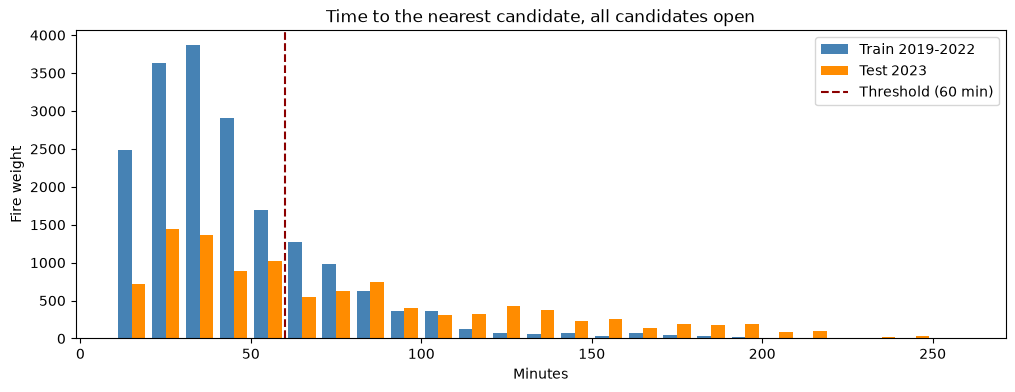

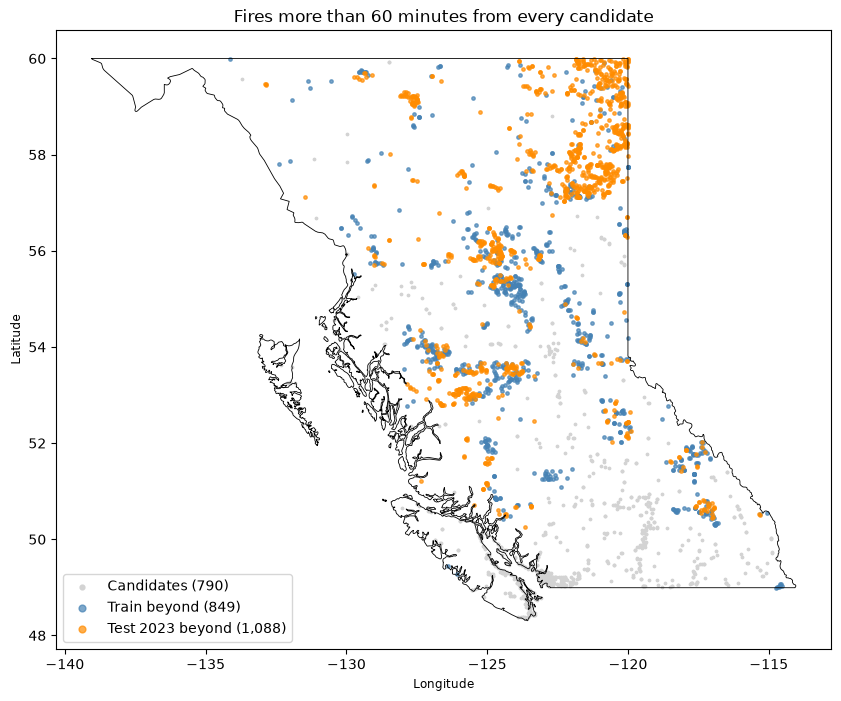

In [10]:
nearest_train, nearest_test = cost_train.min(axis=1), cost_test.min(axis=1)
bins = np.arange(DISPATCH_MIN, max(nearest_train.max(), nearest_test.max()) + 10, 10)
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist([nearest_train, nearest_test], bins=bins, weights=[demand_train["weight"], demand_test["weight"]],
        label=[f"Train {TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]}", "Test 2023"], color=["steelblue", "darkorange"])
ax.axvline(THRESHOLD_MIN, color="darkred", linestyle="--", label=f"Threshold ({THRESHOLD_MIN} min)")
ax.set(title="Time to the nearest candidate, all candidates open", xlabel="Minutes", ylabel="Fire weight")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 9))
bc.boundary.plot(ax=ax, color="black", linewidth=0.6)
ax.scatter(candidates["lon"], candidates["lat"], s=3, color="lightgrey", label=f"Candidates ({len(candidates)})")
for frame, nearest, color, label in [(demand_train, nearest_train, "steelblue", "Train"),
                                     (demand_test, nearest_test, "darkorange", "Test 2023")]:
    beyond = frame[nearest > THRESHOLD_MIN]
    ax.scatter(beyond["lon"], beyond["lat"], s=6, color=color, alpha=0.7, label=f"{label} beyond ({len(beyond):,})")
ax.set(title=f"Fires more than {THRESHOLD_MIN} minutes from every candidate", xlabel="Longitude", ylabel="Latitude")
ax.legend(markerscale=2)
plt.show()

## 8. Checks

In [11]:
def hand_minutes(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, (lat1, lon1, lat2, lon2))
    a = math.sin((lat2 - lat1) / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(a)) * DETOUR / SPEED_KMH * 60 + DISPATCH_MIN


row, column = len(demand_train) // 2, len(candidates) // 2
by_hand = hand_minutes(demand_train.at[row, "lat"], demand_train.at[row, "lon"],
                       candidates.at[column, "lat"], candidates.at[column, "lon"])
matrices = {"cost_train": (cost_train, demand_train), "cost_test": (cost_test, demand_test),
            "cost_cells": (cost_cells, demand_cells)}
candidate_points = gpd.GeoSeries(gpd.points_from_xy(candidates["lon"], candidates["lat"]), crs="EPSG:4326")
checks = {
    "matrix shapes match demand and candidates": all(m.shape == (len(d), len(candidates)) for m, d in matrices.values()),
    "no NaN in matrices": not any(np.isnan(m).any() for m, _ in matrices.values()),
    f"every value >= DISPATCH_MIN ({DISPATCH_MIN})": all(m.min() >= DISPATCH_MIN for m, _ in matrices.values()),
    "every candidate inside BC": bool(candidate_points.within(bc_shape).all()),
    "cand_id equals column index": bool((candidates["cand_id"] == np.arange(len(candidates))).all()),
    "cell weight equals train weight": bool(np.isclose(demand_cells["weight"].sum(), demand_train["weight"].sum())),
    "no static suspects in demand": not ignitions.set_index("fire_id").loc[demand["fire_id"], "static_suspect"].any(),
    f"spot check [{row}, {column}]: matrix {cost_train[row, column]:.3f} vs hand {by_hand:.3f}":
        abs(cost_train[row, column] - by_hand) < 0.01,
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")
if not all(checks.values()):
    raise ValueError("A check failed; nothing was saved.")

PASS  matrix shapes match demand and candidates
PASS  no NaN in matrices
PASS  every value >= DISPATCH_MIN (10)
PASS  every candidate inside BC
PASS  cand_id equals column index
PASS  cell weight equals train weight
PASS  no static suspects in demand
PASS  spot check [2335, 395]: matrix 569.464 vs hand 569.464


## 9. Save

In [12]:
candidates.to_parquet(MODEL_DIR / "candidates.parquet", index=False)
demand_train.to_parquet(MODEL_DIR / "demand_train.parquet", index=False)
demand_test.to_parquet(MODEL_DIR / "demand_test.parquet", index=False)
demand_cells.to_parquet(MODEL_DIR / "demand_cells.parquet", index=False)
np.save(MODEL_DIR / "cost_train.npy", cost_train)
np.save(MODEL_DIR / "cost_test.npy", cost_test)
np.save(MODEL_DIR / "cost_cells.npy", cost_cells)
config = {
    "DETOUR": DETOUR, "SPEED_KMH": SPEED_KMH, "DISPATCH_MIN": DISPATCH_MIN, "THRESHOLD_MIN": THRESHOLD_MIN,
    "CELL_KM": CELL_KM, "HALL_MERGE_M": HALL_MERGE_M, "TOWN_MERGE_KM": TOWN_MERGE_KM,
    "TRAIN_YEARS": TRAIN_YEARS, "TEST_YEARS": TEST_YEARS, "PLACE_RANK": PLACE_RANK,
    "EARTH_RADIUS_KM": EARTH_RADIUS_KM, "OVERPASS_URL": OVERPASS_URL, "OVERPASS_TIMEOUT_S": OVERPASS_TIMEOUT_S,
    "OVERPASS_ATTEMPTS": OVERPASS_ATTEMPTS, "OVERPASS_USER_AGENT": OVERPASS_USER_AGENT,
    "OVERPASS_QUERY": OVERPASS_QUERY.strip(),
    "osm_query_date": OSM_QUERY_DATE, "osm_data_timestamp": OSM_DATA_TIMESTAMP,
    "static_suspects_excluded": STATIC_EXCLUDED, "weight_cap": WEIGHT_CAP, "reach_km": round(REACH_KM, 2),
    "n_halls": int(is_hall.sum()), "n_towns": int(is_town.sum()), "n_candidates": len(candidates),
    "n_demand_train": len(demand_train), "n_demand_test": len(demand_test), "n_demand_cells": len(demand_cells),
}
(MODEL_DIR / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
for path in sorted(MODEL_DIR.iterdir()):
    print(f"{path.stat().st_size / 1e6:8.2f} MB  {path.relative_to(REPO_ROOT)}")

    0.03 MB  data\processed\model\candidates.parquet
    0.00 MB  data\processed\model\config.json
    7.24 MB  data\processed\model\cost_cells.npy
    7.46 MB  data\processed\model\cost_test.npy
   14.76 MB  data\processed\model\cost_train.npy
    0.07 MB  data\processed\model\demand_cells.parquet
    0.08 MB  data\processed\model\demand_test.parquet
    0.16 MB  data\processed\model\demand_train.parquet
